# Fast Gradient Sign Method (FGSM)

**Framework:** PyTorch  
**Dataset:** MNIST  

### Aim

This laboratory studies adversarial perturbations against a trained image classifier using the Fast Gradient Sign Method (FGSM).

The objective is not only to execute an attack, but to connect the **threat model**, **mathematical formulation**, and **PyTorch implementation**. The attack is first constructed on one image so that the loss, input gradient, gradient sign, perturbation, and adversarial image can all be inspected. It is then evaluated on the complete MNIST test set.

By the end of the laboratory, you should be able to explain:

- how an adversarial attack is characterized by lifecycle stage, attacker capability, attacker knowledge, security objective, and targetedness;
- what changes during ordinary training and what changes during FGSM;
- the difference between $\nabla_\theta\mathcal{L}$ and $\nabla_x\mathcal{L}$;
- the roles of $\delta$, $\epsilon$, $\ell_\infty$, `sign`, and clipping;
- the mathematical and implementation differences between untargeted and targeted FGSM.

## 1. Attack scenario and characterization

Consider the following situation.

A convolutional neural network has already been trained to classify MNIST digits. A test image $x$ has true label $y=7$, and the trained model initially classifies it correctly.

Before the image is submitted to the classifier, an attacker can modify the pixel values of that test image. The attacker:

- does not change the training dataset;
- does not update or replace the trained model parameters;
- has access to the trained model's architecture, parameters, and loss computation, so gradients through the target model can be computed;
- wants the classifier to stop predicting the correct class $7$; any other digit is sufficient for the attack goal;
- must keep the modification small: if $x_{\mathrm{adv}}=x+\delta$, then
  $$
  \|\delta\|_\infty \le \epsilon;
  $$
- must keep the resulting MNIST pixel values in the valid numerical range $[0,1]$.

The attack will later be implemented with FGSM. 

### Exercise 1 - Characterize the scenario

Complete the table. In the **evidence** column, point to the specific fact in the scenario that supports your classification.

| Dimension | Classification in this laboratory | Evidence from the scenario |
|---|---|---|
| Stage of the ML lifecycle attacked | Deployment | we modifie the input image directly on the deployed model|
| Attack family | Adverserial Machine Learning |  |
| Security property threatened | | |
| Attacker capability | | |
| Attacker knowledge | Gray boxe | The attacker have acces to the architechture, parameters and more |
| Targeted or untargeted? | untargeted | the goal is just to mislead the model not to control the output (we just want the model to predict wrong) |
| Perturbation norm | | |
| Is the training set modified? | No | the attack does not change the trainning dataset|
| Are model parameters modified during the attack? | No | the attacks is perform on the deployement stage |

**Question 1.** Which single assumption in the scenario is the strongest evidence for your attacker-knowledge classification? How would the knowledge classification change if the attacker could only submit images to an API and observe the returned class label?


**Student response**
<br><br>
* The attacker has access to the trained model's architecture, parameters, and loss computation, so gradients through the target model can be computed;
<br><br>
* The attacker kwnoledge would have change to Black-Box, because he don't know the architechture and can only interact with the output labels returned by the model


## 2. Data and input representation

We use `transforms.ToTensor()` without an additional `Normalize(mean, std)` transform.

For the standard 8-bit MNIST PIL images, `ToTensor()` converts pixel intensities from $[0,255]$ to floating-point values in $[0,1]$.

Therefore, in **this notebook**:

$$
0 \le x_i \le 1.
$$

This is why clipping to $[0,1]$ later is appropriate.

This is not a universal property of every preprocessing pipeline. If mean/std normalization were added, the model-input domain would change and the attack would have to be formulated consistently with that preprocessing.

In [6]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.14.1+cpu
Device: cpu


In [7]:
# Standard MNIST images are 8-bit grayscale images.
# ToTensor() maps them to float tensors in [0, 1].
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print("Training examples:", len(train_dataset))
print("Test examples:", len(test_dataset))

Training examples: 60000
Test examples: 10000


### 2.1 Inspect the actual tensors

Batch shape: torch.Size([128, 1, 28, 28])
Data type: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0


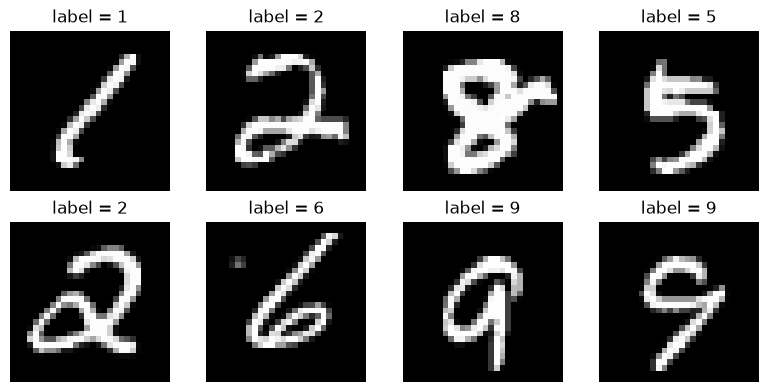

In [8]:
images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)
print("Data type:", images.dtype)
print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())

fig, axes = plt.subplots(2, 4, figsize=(8, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"label = {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

**Question 2.** Why is it useful to inspect the actual tensor range? What would change if `Normalize(mean, std)` were added after `ToTensor()`?

**Student response**

* Checking the actual range lets you verify that ToTensor() has correctly converted the MNIST pixels from [0, 255] to floats in [0, 1]. This is important for properly interpreting pixel intensity and for choosing the epsilon and clipping bounds for the FGSM attack.

* With Normalize(mean, std) after ToTensor(), each value would become (x - mean) / std: so the tensors wouldn’t be in [0, 1] anymore. The model would then need to take these normalized inputs, and epsilon and clipping would need to account for this transformation. For example, the clipping corresponding to pixels [0, 1] would be $[-mean/std, (1-mean)/std]$, not [0, 1].
<br>

## 3. Train a clean classifier

During ordinary training, the model parameters are updated:

$$
\theta \leftarrow \theta-\eta\nabla_\theta\mathcal{L}.
$$

`loss.backward()` computes gradients and `optimizer.step()` changes $\theta$.

During FGSM, `optimizer.step()` will **not** be called. The trained model will remain fixed and the input will be modified instead.

In [9]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Expected model input:
        #   x.shape = [B, 1, 28, 28]
        # where:
        #   B  = batch size,
        #   1  = one grayscale input channel,
        #   28 x 28 = MNIST image height and width.

        # Convolution 1:
        #   1 input channel -> 16 learned feature maps.
        # kernel_size=3 examines local 3x3 neighborhoods.
        # padding=1 preserves the spatial size because stride=1:
        #   [B, 1, 28, 28] -> [B, 16, 28, 28]
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1,
        )

        # Convolution 2:
        #   16 input feature maps -> 32 learned feature maps.
        # Again, padding=1 preserves height and width:
        #   [B, 16, 14, 14] -> [B, 32, 14, 14]
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1,
        )

        # After two 2x2 max-pooling operations:
        #   28 x 28 -> 14 x 14 -> 7 x 7.
        # Therefore the tensor before the first fully connected layer is
        # [B, 32, 7, 7], which contains 32*7*7 = 1568 values per image.
        #
        # fc1 maps these 1568 values to a 64-dimensional hidden representation.
        self.fc1 = nn.Linear(32 * 7 * 7, 64)

        # fc2 maps the 64 hidden features to 10 output logits:
        # one logit for each MNIST class 0, 1, ..., 9.
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # Input:
        # [B, 1, 28, 28]

        # conv1 learns 16 feature maps; ReLU keeps the same shape.
        x = F.relu(self.conv1(x))
        # Shape: [B, 16, 28, 28]

        # 2x2 max-pooling halves height and width.
        x = F.max_pool2d(x, 2)
        # Shape: [B, 16, 14, 14]

        # conv2 learns 32 higher-level feature maps.
        x = F.relu(self.conv2(x))
        # Shape: [B, 32, 14, 14]

        # Second 2x2 max-pooling.
        x = F.max_pool2d(x, 2)
        # Shape: [B, 32, 7, 7]

        # Flatten only the feature dimensions.
        # start_dim=1 keeps the batch dimension B unchanged.
        x = torch.flatten(x, start_dim=1)
        # Shape: [B, 1568]

        # Hidden fully connected representation.
        x = F.relu(self.fc1(x))
        # Shape: [B, 64]

        # Final output: 10 logits, one for each digit class.
        # CrossEntropyLoss expects logits, so no softmax is applied here.
        x = self.fc2(x)
        # Shape: [B, 10]

        return x


model = SmallCNN().to(device)
print(model)


SmallCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


### 3.1 Check the tensor shapes

The comments in the model give the expected shape at each stage. Complete the table without running any additional code.

| Location in the network | Expected tensor shape | What the dimensions represent |
|---|---|---|
| Model input | [B, 1, 28, 28] | Batch, canal en niveaux de gris, hauteur, largeur |
| After `conv1` + ReLU | [B, 16, 28, 28] | 16 cartes de caractéristiques ; les dimensions spatiales sont conservées |
| After first max-pooling |[B, 16, 14, 14]  | 16 cartes, hauteur et largeur réduites de moitié |
| After `conv2` + ReLU | [B, 32, 14, 14] | 32 cartes de caractéristiques ; dimensions spatiales conservées |
| After second max-pooling | [B, 32, 7, 7] | 32 cartes, chacune de taille 7 × 7 |
| After `torch.flatten(..., start_dim=1)` | [B, 1568] | 32 × 7 × 7 = 1568 caractéristiques par image |
| After `fc1` + ReLU | [B, 64] | 64 caractéristiques cachées par image |
| Final logits | [B, 10] | 10 scores, un pour chaque chiffre de 0 à 9|

**Question.** Why does `fc1` need `32 * 7 * 7` input features? Why does `fc2` have exactly 10 outputs?


**Student response**

fc1 needs 32 * 7 * 7 inputs because after the two convolutions and the two max-poolings, each image is represented by 32 feature maps of size 7 × 7. Flattening thus gives 1568 values per image. fc2 produces exactly 10 outputs, since MNIST has 10 classes (the digits 0 to 9); each output is the logit associated with a class.
<br>

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 2

for epoch in range(EPOCHS):
    # Training mode enables the normal training behaviour of the model.
    # Our SmallCNN has no dropout or batch-normalization layers, but using
    # model.train() is still the standard and explicit choice during training.
    model.train()

    # These three variables accumulate statistics over the whole epoch.
    correct = 0
    total = 0
    running_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # 1. Clear parameter gradients left from the previous mini-batch.
        optimizer.zero_grad()

        # 2. Forward pass.
        # logits.shape = [batch_size, 10].
        logits = model(x_batch)

        # 3. Compute cross-entropy loss for this mini-batch.
        # By default, CrossEntropyLoss returns the MEAN loss over the batch.
        loss = criterion(logits, y_batch)

        # 4. Compute gradients of the loss with respect to model parameters:
        #    dL/dtheta.
        loss.backward()

        # 5. Update the model parameters theta.
        optimizer.step()

        # loss.item() is the mean loss of this mini-batch.
        # Multiplying by the batch size converts it back to the summed
        # contribution of this batch. At the end of the epoch we divide
        # running_loss by total to obtain the mean loss per example.
        running_loss += loss.item() * y_batch.size(0)

        # logits.argmax(dim=1) returns one predicted class index per image.
        # Shape:
        #   logits                  -> [batch_size, 10]
        #   logits.argmax(dim=1)    -> [batch_size]
        #
        # Comparing predictions with y_batch creates a Boolean tensor.
        # .sum() counts how many predictions in this batch are correct.
        correct += (
            logits.argmax(dim=1) == y_batch
        ).sum().item()

        # y_batch.size(0) is the number of examples in the current batch.
        # The final batch can be smaller than the nominal batch size,
        # so we count the actual number processed.
        total += y_batch.size(0)

    mean_epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"loss={mean_epoch_loss:.4f} | "
        f"accuracy={100 * epoch_accuracy:.2f}%"
    )


Epoch 1/2 | loss=0.3422 | accuracy=89.89%
Epoch 2/2 | loss=0.0795 | accuracy=97.58%


In [11]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        predictions = logits.argmax(dim=1)

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

clean_accuracy = correct / total
print(f"Clean test accuracy: {100 * clean_accuracy:.2f}%")

Clean test accuracy: 98.14%


**Question 3.** What changes during ordinary training? What changes during FGSM? Explain the difference between $\nabla_\theta\mathcal{L}$ and $\nabla_x\mathcal{L}$.

**Student response**

* During ordinary training, the model’s parameters (weights and biases, denoted by (\theta)) are updated to reduce the loss. The training images remain unchanged. The gradient $\nabla_\theta \mathcal{L}$ tells us how the loss changes when the model parameters change, and the optimizer uses it to update those parameters.
* During FGSM, the model parameters are kept fixed, and the input image (x) is modified to increase the loss. The gradient $\nabla_x \mathcal{L}$ tells us how the loss changes with respect to each input pixel. FGSM uses its sign to create the adversarial image

## 4. Untargeted FGSM on one image

An untargeted attack seeks **any incorrect prediction**.

The optimization problem is

$$
\max_{\|\delta\|_\infty\le\epsilon}
\mathcal{L}(f_\theta(x+\delta),y).
$$

FGSM uses

$$
\delta
=
\epsilon\operatorname{sign}
\left(\nabla_x\mathcal{L}(f_\theta(x),y)\right),
$$

then

$$
x_{\mathrm{adv}}
=
\operatorname{clip}_{[0,1]}(x+\delta).
$$

### 4.1 Select a clean image before attacking it

We first choose one image that the model classifies correctly **before any perturbation is applied**.

This matters because if the model is already wrong on the clean image, a later wrong prediction cannot be attributed to the attack.

There are two distinct phases:

**Clean inference**

- the image is not modified;
- gradients are not needed;
- `torch.no_grad()` is used;
- we record the clean prediction and class probabilities.

**Attack generation**

- the same clean image is copied;
- the model parameters remain fixed;
- gradients are enabled for the **input** using `requires_grad_(True)`;
- the gradient is used to construct a perturbation $\delta$;
- the model is then evaluated again on $x_{\mathrm{adv}}=x+\delta$.

We use a correctly classified digit 7 so that the before/after behaviour is easy to follow.


Selected clean image
--------------------
True class: 7
Clean predicted class: 7
P(class 7): 0.9999264478683472


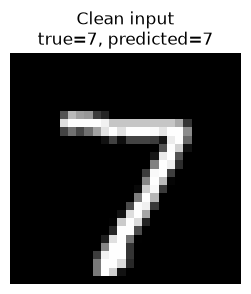

In [12]:
# Put the trained model in evaluation mode.
# model.eval() does not compute an attack and does not modify the model.
# It simply tells layers such as dropout/batch-normalization to use
# evaluation behaviour. Our SmallCNN has neither, but this is good practice.
model.eval()

# Search the MNIST test set for a digit 7 that the trained model
# already classifies correctly.
#
# We search instead of hard-coding a dataset index because the exact model
# obtained after training can vary slightly between runs.
for image, label in test_dataset:
    # Ignore test images that are not class 7.
    if label != 7:
        continue

    # The dataset returns one MNIST image with shape:
    # [channels, height, width] = [1, 28, 28].
    #
    # The neural network is written to process batches of images.
    # Conv2d therefore expects:
    # [batch_size, channels, height, width].
    #
    # Since we are evaluating only one image, batch_size = 1.
    # unsqueeze(0) inserts this batch dimension:
    #
    # [1, 28, 28]  ->  [1, 1, 28, 28]
    #  C   H   W        B  C   H   W
    candidate = image.unsqueeze(0).to(device)

    # This is CLEAN inference, not attack generation.
    # We only need a prediction, so no gradient graph is required.
    with torch.no_grad():
        candidate_logits = model(candidate)
        candidate_pred = candidate_logits.argmax(dim=1).item()

    # Stop when we find a class-7 image that is correctly classified.
    if candidate_pred == label:
        x = candidate
        y = torch.tensor([label], dtype=torch.long, device=device)
        break

# Evaluate the selected clean image once more so that we can keep
# both logits and probabilities for later before/after comparison.
with torch.no_grad():
    clean_logits = model(x)

    # Softmax is used here only to make the logits interpretable as
    # class probabilities for visualization. The training loss itself
    # still receives raw logits.
    clean_probs = torch.softmax(clean_logits, dim=1)

    # argmax returns the class with the largest logit.
    clean_pred = clean_logits.argmax(dim=1).item()

print("Selected clean image")
print("--------------------")
print("True class:", y.item())
print("Clean predicted class:", clean_pred)
print("P(class 7):", clean_probs[0, 7].item())

# x[0, 0] means:
#   first image in the batch,
#   first (and only) grayscale channel.
plt.figure(figsize=(3, 3))
plt.imshow(x[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
plt.title(
    f"Clean input\n"
    f"true={y.item()}, predicted={clean_pred}"
)
plt.axis("off")
plt.show()


### 4.2 Compute $\nabla_x\mathcal{L}$

The model is not retrained. Instead, we ask PyTorch to compute the derivative of the loss with respect to the **input pixels**.

In [13]:
# Make a separate copy of the clean image for attack generation.
# detach() ensures this tensor is not connected to any previous graph.
# clone() gives us an independent tensor that can be modified safely.
x_attack = x.clone().detach()

# During clean inference we did not need gradients.
# During FGSM we DO need the gradient of the loss with respect to the input,
# so we explicitly enable gradient tracking for x_attack.
x_attack.requires_grad_(True)

# Forward pass through the SAME trained model.
# The model parameters are not changed.
logits = model(x_attack)

# Untargeted FGSM uses the TRUE label y in the loss.
# Intuition: the attacker will try to make the model perform worse
# with respect to the correct class.
loss = criterion(logits, y)

# Clear any parameter gradients that may still be stored in the model.
# This does not change the model weights.
model.zero_grad()

# Backpropagation computes derivatives.
# Because x_attack.requires_grad=True, PyTorch stores dL/dx in x_attack.grad.
loss.backward()

# gradient has the same shape as the input:
# [1, 1, 28, 28].
# Each value tells how a small local change to that pixel affects the loss.
gradient = x_attack.grad.detach()

print("Untargeted attack: input-gradient information")
print("---------------------------------------------")
print("Loss before attack:", loss.item())
print("Input shape:", tuple(x_attack.shape))
print("Gradient shape:", tuple(gradient.shape))
print("Minimum gradient value:", gradient.min().item())
print("Maximum gradient value:", gradient.max().item())
print("Mean absolute gradient:", gradient.abs().mean().item())


Untargeted attack: input-gradient information
---------------------------------------------
Loss before attack: 7.354942499659956e-05
Input shape: (1, 1, 28, 28)
Gradient shape: (1, 1, 28, 28)
Minimum gradient value: -7.752446981612593e-05
Maximum gradient value: 4.3273033952573314e-05
Mean absolute gradient: 5.624508048640564e-06


### 4.3 Visualize the input gradient and its sign

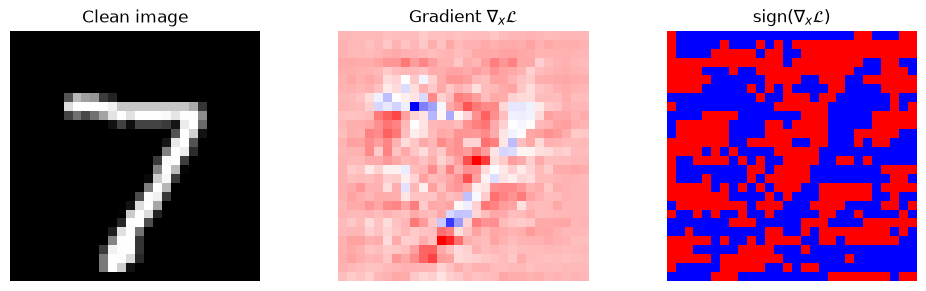

In [14]:
gradient_sign = gradient.sign()

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(x[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Clean image")

axes[1].imshow(gradient[0, 0].cpu(), cmap="bwr")
axes[1].set_title(r"Gradient $\nabla_x\mathcal{L}$")

axes[2].imshow(
    gradient_sign[0, 0].cpu(),
    cmap="bwr",
    vmin=-1,
    vmax=1,
)
axes[2].set_title(r"$\operatorname{sign}(\nabla_x\mathcal{L})$")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Question 4.**

1. What does the raw gradient tell us about each pixel?
2. What information is removed by `sign()`?
3. If two positive gradient components are `0.002` and `4.0`, what perturbation does standard $\ell_\infty$ FGSM apply to each when $\epsilon=0.1$?

**Student response**
<br>
1 - The raw gradient indicates how sensitive the loss is to each pixel, including whether increasing that pixel raises or lowers the loss and by how much locally.<br><br>
2 - sign() keeps only the direction of each gradient component (positive, negative, or zero). It discards the magnitude, so it treats small and large gradients alike.<br><br>
3 - Both positive components become +1 after sign(). Standard $\ell_\infty$ FGSM therefore adds $\epsilon=0.1$ to each pixel: the perturbations are +0.1 and +0.1, respectively.
<br>

### 4.4 Construct the perturbation — student implementation

In [ ]:
epsilon = 0.15

# TODO 1:
# Implement delta = epsilon * sign(gradient)
delta = ...

# TODO 2:
# Add the perturbation to the input.
x_adv_before_clip = ...

# TODO 3:
# Keep every pixel in the valid [0, 1] range.
x_adv = ...

# The actual perturbation may be smaller at pixels affected by clipping.
actual_delta = x_adv - x_attack.detach()

In [ ]:
print("epsilon:", epsilon)
print("Largest |delta| before clipping:", delta.abs().max().item())
print("Largest |delta| after clipping:", actual_delta.abs().max().item())
print("Minimum adversarial pixel:", x_adv.min().item())
print("Maximum adversarial pixel:", x_adv.max().item())

### 4.5 Inspect the complete FGSM construction

Read the figure from left to right:

1. **Clean input:** the unmodified image.
2. **Input gradient:** how the true-label loss changes locally with each pixel.
3. **Gradient sign:** only the direction of change is retained.
4. **Perturbation:** the actual change added to the image; it is amplified only for display.
5. **Adversarial input:** the image actually submitted to the classifier after perturbation and clipping.

The gradient, gradient sign, and perturbation are different objects. The model is evaluated on the final adversarial image, not on the gradient visualization or the amplified perturbation.


In [ ]:
# Obtain the prediction of the adversarial image so that the clean and
# adversarial classes can be shown directly in the figure.
with torch.no_grad():
    adv_pred_for_plot = model(x_adv).argmax(dim=1).item()

# Create five panels showing the FGSM construction from left to right.
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))

# Panel 1: original image.
# No perturbation has been applied here.
axes[0].imshow(
    x[0, 0].cpu(),
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[0].set_title(
    f"1. Clean input\n"
    f"true={y.item()}, pred={clean_pred}"
)

# Panel 2: raw input gradient dL/dx.
# Positive and negative values indicate opposite local directions.
# This is NOT yet the perturbation.
axes[1].imshow(
    gradient[0, 0].cpu(),
    cmap="bwr",
)
axes[1].set_title(
    "2. Input gradient\n"
    r"$\nabla_x\mathcal{L}$"
)

# Panel 3: FGSM discards gradient magnitude and keeps only direction.
# Values are -1, 0, or +1.
axes[2].imshow(
    gradient_sign[0, 0].cpu(),
    cmap="bwr",
    vmin=-1,
    vmax=1,
)
axes[2].set_title(
    "3. Gradient sign\n"
    r"$\operatorname{sign}(\nabla_x\mathcal{L})$"
)

# Panel 4: actual perturbation after clipping.
# We multiply it by 4 ONLY to make it visible in the figure.
# The classifier is never evaluated on 4*delta.
displayed_delta = 4 * actual_delta[0, 0].cpu()

axes[3].imshow(
    displayed_delta,
    cmap="bwr",
    vmin=-4 * epsilon,
    vmax=4 * epsilon,
)
axes[3].set_title(
    "4. Perturbation shown x4\n"
    rf"$\|\delta\|_\infty={actual_delta.abs().max().item():.3f}$"
)

# Panel 5: the actual adversarial input sent to the model.
axes[4].imshow(
    x_adv[0, 0].detach().cpu(),
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[4].set_title(
    f"5. Adversarial input\n"
    f"true={y.item()}, pred={adv_pred_for_plot}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


### 4.6 Compare loss, probabilities, and prediction

In [ ]:
with torch.no_grad():
    adv_logits = model(x_adv)
    adv_probs = torch.softmax(adv_logits, dim=1)
    adv_pred = adv_logits.argmax(dim=1).item()

    # Same true label y: we measure how the attack changed the true-label loss.
    adv_loss = criterion(adv_logits, y).item()

print("True label:", y.item())
print("Clean prediction:", clean_pred)
print("Adversarial prediction:", adv_pred)
print()
print("True-label loss before attack:", loss.item())
print("True-label loss after attack:", adv_loss)
print()
print("P(true class) before:", clean_probs[0, y.item()].item())
print("P(true class) after:", adv_probs[0, y.item()].item())
print()
print("Attack successful?", adv_pred != y.item())

In [ ]:
classes = np.arange(10)

plt.figure(figsize=(8, 4))

plt.bar(
    classes - 0.18,
    clean_probs[0].cpu().numpy(),
    width=0.36,
    label="Clean",
)

plt.bar(
    classes + 0.18,
    adv_probs[0].cpu().numpy(),
    width=0.36,
    label="Adversarial",
)

plt.xticks(classes)
plt.xlabel("MNIST class")
plt.ylabel("Probability")
plt.title("Class probabilities before and after untargeted FGSM")
plt.legend()
plt.show()

**Question 5.**

1. Did the true-class loss increase?
2. Did the probability of the true class decrease?
3. Did the predicted class change?
4. Why can the loss increase without necessarily changing the prediction?
5. Why can the actual perturbation be smaller than $\epsilon$ after clipping?

**Student response**

<br><br><br><br><br><br><br>

## 5. Write the untargeted FGSM function

Now implement the same three operations in a reusable function:

$$
x_{\mathrm{adv}}
=
\operatorname{clip}_{[0,1]}
\left(
x+\epsilon\operatorname{sign}(\nabla_x\mathcal{L})
\right).
$$

In [ ]:
def fgsm_untargeted(x, gradient, epsilon):
    # gradient has the same shape as x.
    # Each element is dL/dx_i for one input pixel.

    # TODO 1:
    # Keep only the direction of every gradient component.
    # Expected values: -1, 0, or +1.
    gradient_sign = ...

    # TODO 2:
    # Untargeted FGSM tries to INCREASE the loss for the true class.
    # Therefore, move in the POSITIVE gradient-sign direction:
    # x_adv = x + epsilon * sign(gradient)
    x_adv = ...

    # TODO 3:
    # The MNIST inputs in this notebook are in [0, 1].
    # Clip the perturbed image back to this valid numerical range.
    x_adv = ...

    return x_adv


### 5.1 Observe the effect of different $\epsilon$ values on the same image

In [ ]:
epsilons = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

fig, axes = plt.subplots(1, len(epsilons), figsize=(14, 2.5))

for ax, eps in zip(axes, epsilons):
    image_adv = fgsm_untargeted(
        x_attack.detach(),
        gradient,
        eps,
    )

    with torch.no_grad():
        output_adv = model(image_adv)
        pred_adv = output_adv.argmax(dim=1).item()
        loss_adv = criterion(output_adv, y).item()

    ax.imshow(image_adv[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"eps={eps:.2f}\n"
        f"pred={pred_adv}\n"
        f"loss={loss_adv:.2f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

**Question 6.** Describe what happens as $\epsilon$ increases. Discuss both attack effectiveness and visual distortion. Why must $\epsilon$ be reported with any FGSM robustness result?

**Student response**

<br><br><br><br><br><br><br>

## 6. Evaluate untargeted FGSM on the full test set

We now use one simple loop over `test_loader`.

**Robust accuracy**

$$
\mathrm{RobustAccuracy}
=
\frac{\#\{f_\theta(x_{\mathrm{adv}})=y\}}{N}.
$$

**Attack success rate**

$$
\mathrm{ASR}
=
\frac{
\#\{f_\theta(x)=y \ \text{and}\ f_\theta(x_{\mathrm{adv}})\ne y\}
}{
\#\{f_\theta(x)=y\}
}.
$$

A sample that was already wrong before the attack is not counted as an attack success.

In [ ]:
def evaluate_fgsm(model, test_loader, epsilon):
    model.eval()

    total = 0
    robust_correct = 0

    initially_correct = 0
    successful_attacks = 0

    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Clean prediction.
        with torch.no_grad():
            clean_logits = model(x_batch)
            clean_pred = clean_logits.argmax(dim=1)

        clean_correct = clean_pred.eq(y_batch)
        initially_correct += clean_correct.sum().item()

        # Compute dL/dx for the batch.
        x_attack = x_batch.clone().detach()
        x_attack.requires_grad_(True)

        logits = model(x_attack)
        loss = criterion(logits, y_batch)

        model.zero_grad()
        loss.backward()

        gradient = x_attack.grad.detach()

        # Generate adversarial examples.
        x_adv = fgsm_untargeted(
            x_attack.detach(),
            gradient,
            epsilon,
        )

        # Evaluate the adversarial batch.
        with torch.no_grad():
            adv_logits = model(x_adv)
            adv_pred = adv_logits.argmax(dim=1)

        robust_correct += adv_pred.eq(y_batch).sum().item()
        total += y_batch.size(0)

        # Successful attack: correct before, wrong after.
        successful = clean_correct & adv_pred.ne(y_batch)
        successful_attacks += successful.sum().item()

    robust_accuracy = robust_correct / total
    attack_success_rate = successful_attacks / initially_correct

    return robust_accuracy, attack_success_rate

In [ ]:
robust_accuracies = []
attack_success_rates = []

for eps in epsilons:
    robust_acc, asr = evaluate_fgsm(model, test_loader, eps)

    robust_accuracies.append(robust_acc)
    attack_success_rates.append(asr)

    print(
        f"epsilon={eps:.2f} | "
        f"robust accuracy={100 * robust_acc:.2f}% | "
        f"ASR={100 * asr:.2f}%"
    )

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(
    epsilons,
    robust_accuracies,
    marker="o",
    label="Robust accuracy",
)

plt.plot(
    epsilons,
    attack_success_rates,
    marker="o",
    label="Attack success rate",
)

plt.xlabel(r"Perturbation budget $\epsilon$")
plt.ylabel("Rate")
plt.ylim(0, 1.05)
plt.title("Untargeted white-box FGSM on MNIST")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Question 7.**

1. What happens at $\epsilon=0$?
2. Why is robust accuracy different from ASR?
3. Why must a cleanly misclassified image be excluded from the numerator of ASR?
4. Summarize how robust accuracy and ASR change with $\epsilon$.

**Student response**

<br><br><br><br><br><br><br>

## 7. Targeted FGSM

The previous attack succeeded when the classifier produced **any class other than the true class**.

Now the attack goal is more specific.

The clean image is still a digit 7, but the attacker chooses the target

$$
y_t=3.
$$

Success now requires

$$
f_\theta(x_{\mathrm{adv}})=3.
$$

It is not enough merely to make the classifier stop predicting 7.

### Mathematical objective

The target class is placed inside the cross-entropy loss:

$$
\mathcal{L}_t
=
\mathcal{L}(f_\theta(x),y_t).
$$

For cross-entropy, reducing this loss encourages the model to assign more probability to the selected target class. Therefore the targeted objective is

$$
\min_{\|\delta\|_\infty\le\epsilon}
\mathcal{L}(f_\theta(x+\delta),y_t).
$$

The corresponding one-step FGSM update is

$$
\delta
=
-\epsilon
\operatorname{sign}
\left(
\nabla_x\mathcal{L}(f_\theta(x),y_t)
\right).
$$

The implementation therefore changes in two places:

- the loss uses the selected target label $y_t$ instead of the true label $y$;
- the input moves in the **negative** gradient-sign direction because the target-class loss must be decreased.

The model parameters remain fixed exactly as in the previous attack.


### 7.1 Compute the target-class gradient

In [ ]:
target_class = 3

# CrossEntropyLoss expects class labels as integer tensors.
# Shape [1] matches our batch containing one image.
y_target = torch.tensor(
    [target_class],
    dtype=torch.long,
    device=device,
)

# Start again from the ORIGINAL clean image, not from the untargeted
# adversarial image. This keeps the two experiments comparable.
x_target = x.clone().detach()

# We need d(target_loss)/dx, so input-gradient tracking is enabled.
x_target.requires_grad_(True)

# Forward pass through the same fixed trained model.
target_logits = model(x_target)

# KEY DIFFERENCE 1:
# The loss uses the attacker-selected TARGET label (3),
# not the true label (7).
target_loss = criterion(target_logits, y_target)

model.zero_grad()
target_loss.backward()

# Gradient of the TARGET-CLASS loss with respect to every input pixel.
target_gradient = x_target.grad.detach()
target_gradient_sign = target_gradient.sign()

# These probabilities are only for interpretation.
with torch.no_grad():
    target_probs_before = torch.softmax(model(x), dim=1)

print("Targeted attack: starting point")
print("--------------------------------")
print("True class:", y.item())
print("Attacker-selected target class:", target_class)
print("Clean predicted class:", clean_pred)
print("Target-class loss before attack:", target_loss.item())
print(
    "P(target class) before attack:",
    target_probs_before[0, target_class].item(),
)
print("Target-gradient shape:", tuple(target_gradient.shape))


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(x[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Clean image")

axes[1].imshow(target_gradient[0, 0].cpu(), cmap="bwr")
axes[1].set_title(r"Target gradient $\nabla_x\mathcal{L}_t$")

axes[2].imshow(
    target_gradient_sign[0, 0].cpu(),
    cmap="bwr",
    vmin=-1,
    vmax=1,
)
axes[2].set_title(r"$\operatorname{sign}(\nabla_x\mathcal{L}_t)$")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Question 8.** Why is class 3 used inside the targeted loss instead of the true class 7? Why does targeted FGSM move in the **negative** gradient-sign direction?

**Student response**

<br><br><br><br><br><br><br>

### 7.2 Implement targeted FGSM

In [ ]:
def fgsm_targeted(x, target_gradient, epsilon):
    # target_gradient = dL_target/dx.

    # TODO 1:
    # Keep only the direction of each target-loss gradient component.
    gradient_sign = ...

    # TODO 2:
    # KEY DIFFERENCE 2:
    # The targeted attack must DECREASE target-class loss.
    # Therefore move in the NEGATIVE gradient-sign direction:
    # x_adv = x - epsilon * sign(target_gradient)
    x_adv = ...

    # TODO 3:
    # Keep the adversarial MNIST image in [0, 1].
    x_adv = ...

    return x_adv


### 7.3 Observe the targeted objective as $\epsilon$ increases

In [ ]:
fig, axes = plt.subplots(1, len(epsilons), figsize=(14, 2.7))

for ax, eps in zip(axes, epsilons):
    image_targeted = fgsm_targeted(
        x_target.detach(),
        target_gradient,
        eps,
    )

    with torch.no_grad():
        output_targeted = model(image_targeted)
        probs_targeted = torch.softmax(output_targeted, dim=1)
        pred_targeted = output_targeted.argmax(dim=1).item()
        loss_targeted = criterion(output_targeted, y_target).item()

    ax.imshow(image_targeted[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"eps={eps:.2f}\n"
        f"pred={pred_targeted}\n"
        f"P(3)={probs_targeted[0, 3].item():.2f}\n"
        f"Lt={loss_targeted:.2f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### 7.4 Inspect one targeted perturbation in detail

In [ ]:
epsilon_targeted = 0.25

# Generate the targeted adversarial image from the ORIGINAL clean image.
x_adv_targeted = fgsm_targeted(
    x_target.detach(),
    target_gradient,
    epsilon_targeted,
)

# Measure the actual perturbation after clipping.
targeted_delta = x_adv_targeted - x_target.detach()

# Evaluate the final adversarial image.
with torch.no_grad():
    targeted_logits_after = model(x_adv_targeted)
    targeted_probs_after = torch.softmax(
        targeted_logits_after,
        dim=1,
    )
    targeted_pred = targeted_logits_after.argmax(dim=1).item()

    # The loss is still evaluated with respect to the chosen target class.
    targeted_loss_after = criterion(
        targeted_logits_after,
        y_target,
    ).item()

print("Targeted attack: before and after")
print("---------------------------------")
print("True class:", y.item())
print("Target class:", target_class)
print("Clean predicted class:", clean_pred)
print("Adversarial predicted class:", targeted_pred)
print()
print("Target loss before:", target_loss.item())
print("Target loss after:", targeted_loss_after)
print()
print(
    "P(target) before:",
    target_probs_before[0, target_class].item(),
)
print(
    "P(target) after:",
    targeted_probs_after[0, target_class].item(),
)
print()
print(
    "Measured ||delta_t||_inf:",
    targeted_delta.abs().max().item(),
)
print(
    "Targeted attack successful?",
    targeted_pred == target_class,
)


In [ ]:
# Four panels summarize the targeted attack for one selected epsilon.
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))

# Original clean image and original model decision.
axes[0].imshow(
    x[0, 0].cpu(),
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[0].set_title(
    f"Clean input\n"
    f"true={y.item()}, pred={clean_pred}"
)

# Raw gradient of TARGET-CLASS loss with respect to the input.
# This gradient is computed using y_target=3 inside the loss.
axes[1].imshow(
    target_gradient[0, 0].cpu(),
    cmap="bwr",
)
axes[1].set_title(
    "Target-loss gradient\n"
    r"$\nabla_x\mathcal{L}_t$"
)

# Actual targeted perturbation after clipping.
# Again, multiplying by 4 is ONLY for visualization.
axes[2].imshow(
    (4 * targeted_delta[0, 0]).cpu(),
    cmap="bwr",
    vmin=-4 * epsilon_targeted,
    vmax=4 * epsilon_targeted,
)
axes[2].set_title(
    "Perturbation shown x4\n"
    rf"$\|\delta_t\|_\infty={targeted_delta.abs().max().item():.3f}$"
)

# Final targeted adversarial input.
# Targeted success requires pred == target_class, not merely pred != true class.
axes[3].imshow(
    x_adv_targeted[0, 0].cpu(),
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[3].set_title(
    f"Targeted input\n"
    f"target={target_class}, pred={targeted_pred}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


**Question 9.**

1. Did target-class loss decrease?
2. Did target-class probability increase?
3. Did the prediction become class 3?
4. If the target probability increases but the predicted class is not 3, has the targeted attack succeeded?
5. Why is targeted misclassification more restrictive than untargeted misclassification?

**Student response**

<br><br><br><br><br><br><br>

## 8. Synthesis exercises

Complete both tables.

### Untargeted versus targeted FGSM

| Property | Untargeted FGSM | Targeted FGSM |
|---|---|---|
| Label used inside the loss | | |
| Objective | | |
| Sign of the update | | |
| Success condition | | |
| Does $\theta$ change? | | |
| Does $x$ change? | | |

### Ordinary training versus FGSM

| Property | Ordinary training | FGSM |
|---|---|---|
| Quantity modified | | |
| Main gradient | | |
| Is `optimizer.step()` called? | | |
| Objective | | |

### Attacker knowledge

Classify and justify:

1. exact target weights + direct gradient access;
2. architecture known, weights unknown, surrogate model trained;
3. API returns only labels;
4. API returns class probabilities but exposes no model internals.

**Student response**

<br><br><br><br><br><br><br>

## 9. Final reflection

**Question 10.** In approximately 150 words, state what this laboratory demonstrates and what it does **not** demonstrate about a real deployed AI system.

Your answer should mention white-box access, digital input control, the $\ell_\infty$ constraint, $\epsilon$, and the distinction between model-level and end-to-end system robustness.

**Student response**

<br><br><br><br><br><br><br>

## References

1. I. J. Goodfellow, J. Shlens, and C. Szegedy, “Explaining and Harnessing Adversarial Examples,” *ICLR*, 2015. arXiv:1412.6572.

2. A. Vassilev, A. Oprea, A. Fordyce, H. Anderson, X. Davies, and M. Hamin, *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations*, NIST AI 100-2e2025, 2025.

3. PyTorch Tutorials, “Adversarial Example Generation.”  
   https://docs.pytorch.org/tutorials/beginner/fgsm_tutorial.html

4. Torchvision documentation, `transforms.ToTensor`.  
   https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html